# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Sam Young

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Lab Overview and Submission

**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.

### Part 1: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern.

### Part 2: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [3]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [4]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
63,what,6
26,it,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [5]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


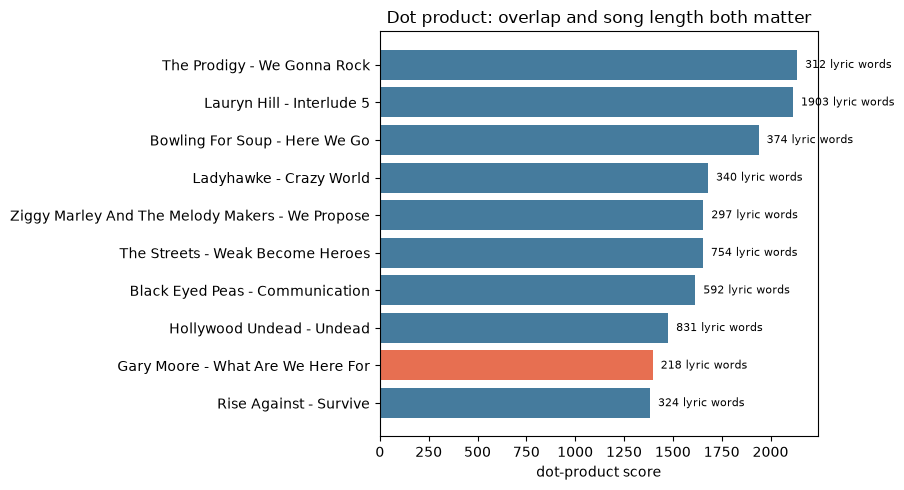

In [6]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

They are similar because they use similar words and they have large song sizes. Larger song size = higher word counts which will significantly increase the dot product value multiplications (before addition). There has to be overlap, but it can be overlap on common words (which "What are we here for" has a lot of). Other songs with many words (such as Lauryn Hill's interlude) are going to have more matches and higher word count values to increase the dot product. The fact that other songs scored a higher dot product than the actual song itself ("What Are We Here For") is an indicator that dot product does not exactly translate to similarity and rewards song size.

In [7]:
results = top_40.copy()

for i, row in top_40.iterrows():

    query_idx_1 = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_1 = X[query_idx_1]

    dot_scores_1 = X @ query_1

    dot_scores_1[query_idx_1] = -np.inf

    top3_idx_1 = np.argsort(dot_scores_1)[::-1][:3]

    results.loc[i, "dot_match_1"] = (
        songs.loc[top3_idx_1[0], "artist_name"]
        + " - "
        + songs.loc[top3_idx_1[0], "song_title"]
    )

    results.loc[i, "dot_match_2"] = (
        songs.loc[top3_idx_1[1], "artist_name"]
        + " - "
        + songs.loc[top3_idx_1[1], "song_title"]
    )

    results.loc[i, "dot_match_3"] = (
        songs.loc[top3_idx_1[2], "artist_name"]
        + " - "
        + songs.loc[top3_idx_1[2], "song_title"]
    )

results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

results

,track_id,song_id,artist_id,artist_name,song_title,genre,dot_match_1,dot_match_2,dot_match_3
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main)
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It)
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version)
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version)
...,...,...,...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Vanilla Ice - Ice Is Workin' It
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version)
557,TRMOUUU128F14ADE16,SOJFEHH12A6BD546BE,ART1UFU1187FB4C9B6,Hawk Nelson,From Underneath,rock,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...
558,TRCURQD128F427C75B,SORFOFF12A8C13B65E,ART1UFU1187FB4C9B6,Hawk Nelson,Turn It On,rock,Daft Punk - Touch It / Technologic,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5


## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [8]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2064.18000,2.580225
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1856.78500,2.320981
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,1767.24000,2.209050
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1617.63000,2.022038
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1599.53625,1.999420
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1516.73875,1.895923
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1510.34125,1.887927
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1352.34875,1.690436
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1313.77875,1.642223
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1312.27875,1.640348


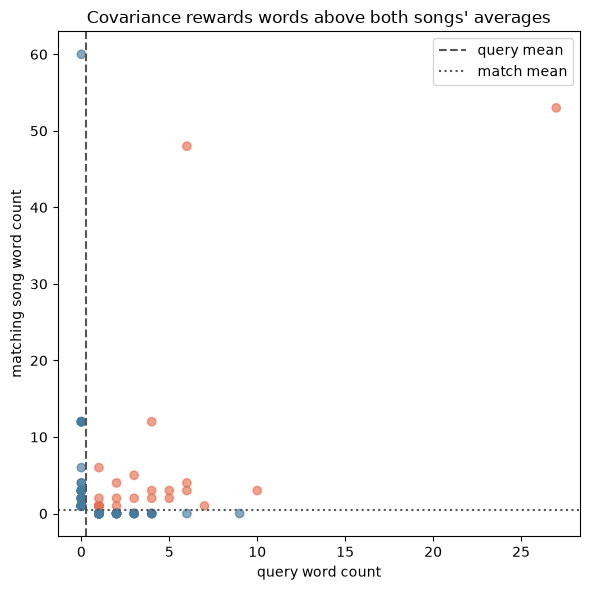

In [9]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

The rankings for the covariance are still very similar to the dot product (the top 5 rankings are identical in both). Subtracting the mean from the values emphasizes how much words are used relative to the average word count per word in the vector. This rewards words that are used very often compared to the average used words. However, because there are so many 0 values in the word count vectors, the mean word count per word in these vectors are very small and close to 0 (highlighted in the graph above). Subtracting this value before preforming the dot product does not make a significant difference in this particular case and that is why the covariance results are so similar to the dot product results. Similarly to the dot product, covariance still rewards songs with high word counts.

In [10]:
X_centered_2 = X - X.mean(axis=1, keepdims=True)

for i, row in top_40.iterrows():

    query_idx_2 = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_2 = X[query_idx_2]

    query_centered_2 = query_2 - query_2.mean()

    centered_dot_scores_2 = X_centered_2 @ query_centered_2

    centered_dot_scores_2[query_idx_2] = -np.inf

    top3_idx_2 = np.argsort(centered_dot_scores_2)[::-1][:3]

    results.loc[i, "centered_match_1"] = (
        songs.loc[top3_idx_2[0], "artist_name"]
        + " - "
        + songs.loc[top3_idx_2[0], "song_title"]
    )

    results.loc[i, "centered_match_2"] = (
        songs.loc[top3_idx_2[1], "artist_name"]
        + " - "
        + songs.loc[top3_idx_2[1], "song_title"]
    )

    results.loc[i, "centered_match_3"] = (
        songs.loc[top3_idx_2[2], "artist_name"]
        + " - "
        + songs.loc[top3_idx_2[2], "song_title"]
    )

results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

results

,track_id,song_id,artist_id,artist_name,song_title,genre,dot_match_1,dot_match_2,dot_match_3,centered_match_1,centered_match_2,centered_match_3
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main)
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It),R. Kelly - I Mean (I Don't Mean It),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Eminem - 8 Mile
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version)
...,...,...,...,...,...,...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5,Vanilla Ice - Ice Is Workin' It,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version)
557,TRMOUUU128F14ADE16,SOJFEHH12A6BD546BE,ART1UFU1187FB4C9B6,Hawk Nelson,From Underneath,rock,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Erykah Badu - I Want You
558,TRCURQD128F427C75B,SORFOFF12A8C13B65E,ART1UFU1187FB4C9B6,Hawk Nelson,Turn It On,rock,Daft Punk - Touch It / Technologic,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5,Daft Punk - Touch It / Technologic,Vanilla Ice - Ice Is Workin' It,Vanilla Ice - It's A Party


## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [11]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.755614
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.746012
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.728089
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.698025
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.696568
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.684930
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.684267
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.679579
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.678728


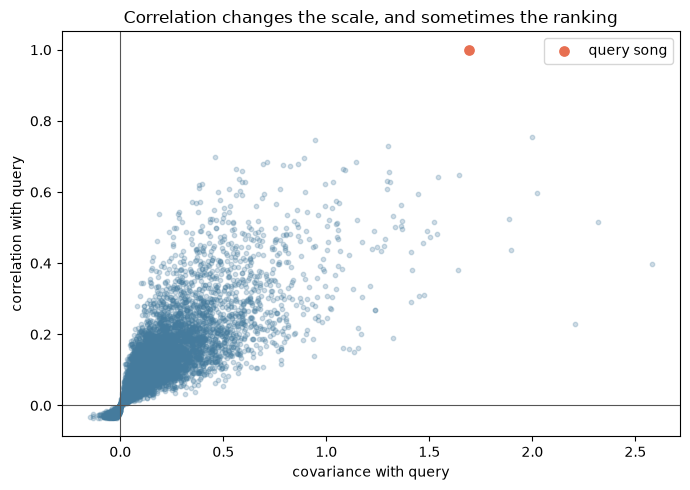

In [12]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

Correlation takes the covariance and divides it by the multiplication of the 2 standard deviations of the 2 vectors being compared. This normalizes the vector and finally takes into account vectors with large word count values and rescales them (through the division of the multiplied standard deviations). Songs that will move up in the correlation rankings (compared to the previous 2 rankings) are songs with fewer word counts but which have similar word usage relative to their means compared to other songs.

In [13]:
X_centered_3 = X - X.mean(axis=1, keepdims=True)
X_std_3 = X.std(axis=1)

for i, row in top_40.iterrows():

    query_idx_3 = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_3 = X[query_idx_3]

    query_centered_3 = query_3 - query_3.mean()

    centered_dot_scores_3 = X_centered_3 @ query_centered_3

    covariance_scores_3 = centered_dot_scores_3 / X.shape[1]

    query_std_3 = query_3.std()
    denom_3 = X_std_3 * query_std_3

    corr_scores_3 = np.divide(
        covariance_scores_3,
        denom_3,
        out=np.zeros_like(covariance_scores_3),
        where=denom_3 != 0,
    )

    corr_scores_3[query_idx_3] = -np.inf

    top3_idx_3 = np.argsort(corr_scores_3)[::-1][:3]

    results.loc[i, "corr_match_1"] = (
        songs.loc[top3_idx_3[0], "artist_name"]
        + " - "
        + songs.loc[top3_idx_3[0], "song_title"]
    )

    results.loc[i, "corr_match_2"] = (
        songs.loc[top3_idx_3[1], "artist_name"]
        + " - "
        + songs.loc[top3_idx_3[1], "song_title"]
    )

    results.loc[i, "corr_match_3"] = (
        songs.loc[top3_idx_3[2], "artist_name"]
        + " - "
        + songs.loc[top3_idx_3[2], "song_title"]
    )

results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

results

,track_id,song_id,artist_id,artist_name,song_title,genre,dot_match_1,dot_match_2,dot_match_3,centered_match_1,centered_match_2,centered_match_3,corr_match_1,corr_match_2,corr_match_3
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It),R. Kelly - I Mean (I Don't Mean It),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Eminem - 8 Mile,Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,The Derek Trucks Band - All I Do,Avalon - Overjoyed,Billie Piper - Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Blues Traveler - Hook,G-Unit - I Don't Want To Talk About It,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5,Vanilla Ice - Ice Is Workin' It,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,M People - It's Your World,Dungeon Family - Trans DF Express,Jeru The Damaja - Physical Stamina
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Momus - Closer To You,Bobby Bare - Numbers,AZ - Rebirth
557,TRMOUUU128F14ADE16,SOJFEHH12A6BD546BE,ART1UFU1187FB4C9B6,Hawk Nelson,From Underneath,rock,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Erykah Badu - I Want You,Clawfinger - Revenge,Angela Bofill - I Try,Rachael Yamagata - Even So
558,TRCURQD128F427C75B,SORFOFF12A8C13B65E,ART1UFU1187FB4C9B6,Hawk Nelson,Turn It On,rock,Daft Punk - Touch It / Technologic,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5,Daft Punk - Touch It / Technologic,Vanilla Ice - Ice Is Workin' It,Vanilla Ice - It's A Party,7 Seconds - Still On It,Gregory Isaac - Soon Forward,Daft Punk - Touch It / Technologic


## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [14]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1.000000
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,0.761523
4677,TROCPYO128F92F9ADC,SOVVPIM12AF72A33E8,AR6097P1187B998E3E,Modern Life Is War,Destination: Death or Better Days,My Love My Way,2006,148.29669,0.647507,0.480729,metal,metalcore; addicting; fury music,204,112,28.301943,0,0.755322
4933,TRYTJTL128F92D1345,SOWNBCM12A8C141160,ARWDDHA1187FB3A745,EDGUY,Superheroes,Fucking With Fire - Live,2005,242.54649,0.722370,0.526279,metal,Power metal; metal; heavy metal; edguy; melodi...,191,75,39.268308,0,0.735159
4489,TRGPMNN128F428B362,SOSAYAA12A8C1393FA,AR6RSHA1187FB3F03F,Raised Fist,Soldiers Of Today,Watch Your Step,1996,152.63302,0.694461,0.457958,metal,hardcore punk,222,95,28.478062,0,0.707435
4521,TRHYEBV12903CE8274,SOHVDHF12AC4685D1D,ARBC4CV1187B9A7823,Lifetime,Daneurysm,Hello Bastards,1995,71.15710,0.714125,0.539633,metal,hardcore; energy; fast; punk; free download,68,32,14.456832,0,0.703254
4550,TRJDFLG128F934B261,SOSLMFL12A8C130DC5,ARK358A1187B9ADDC0,Tourniquet,Convoluted Absolutes,Where Moth And Rust Destroy,2003,337.03138,0.584310,0.398297,metal,metal; Power metal; Progressive metal; heavy m...,189,92,23.194827,0,0.696703
5831,TRLZCAQ128F424D4E4,SOYNGQB12A6D4FD387,AR01SCU1187B9A693C,Street Dogs,Free,State of Grace,2008,219.87220,0.683245,0.486471,punk,irish; Ballad; celtic punk; candidate,291,121,37.349699,0,0.696275
4896,TRXAMNT12903CF43BE,SOSHOZQ12AB017C3B2,ARVXKTV1187FB44139,Arsonists Get All The Girls,Tourtasia,The Game Of Life,2007,227.42159,0.725403,0.454957,metal,deathcore; experimental; grindcore; mathcore; ...,195,118,22.847319,0,0.692076
5184,TRJOQXR128F92EB51A,SOXKDWF12AB017BF6F,ARWSN471187B9A6F7F,Thompson Twins,We Are Detective,Quick Step And Side Kick,1983,182.98730,0.648702,0.441576,pop,80s; new wave; pop; 1980s; alternative,172,91,28.035692,0,0.689013


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

Cosine-similarity seems much more like a similar songs enginge while the dot product seems more like a search engine that values overlapping raw word mass. This is because cosine-similarity divides the dot product by the two vectors' lengths multiplied and normalizes the output. It does not favor songs that have tons of words in its ranking like the dot product does.

In [15]:
def cosine_scores_4(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm

    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


for i, row in top_40.iterrows():

    query_idx_4 = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_4 = X[query_idx_4]

    cos_scores_4 = cosine_scores_4(X, query_4)

    cos_scores_4[query_idx_4] = -np.inf

    top3_idx_4 = np.argsort(cos_scores_4)[::-1][:3]

    results.loc[i, "cosine_match_1"] = (
        songs.loc[top3_idx_4[0], "artist_name"]
        + " - "
        + songs.loc[top3_idx_4[0], "song_title"]
    )

    results.loc[i, "cosine_match_2"] = (
        songs.loc[top3_idx_4[1], "artist_name"]
        + " - "
        + songs.loc[top3_idx_4[1], "song_title"]
    )

    results.loc[i, "cosine_match_3"] = (
        songs.loc[top3_idx_4[2], "artist_name"]
        + " - "
        + songs.loc[top3_idx_4[2], "song_title"]
    )

results.to_csv(
    "./data/top_40_songs_by_genre_results.csv",
    index=False
)

results

,track_id,song_id,artist_id,artist_name,song_title,genre,dot_match_1,dot_match_2,dot_match_3,centered_match_1,centered_match_2,centered_match_3,corr_match_1,corr_match_2,corr_match_3,cosine_match_1,cosine_match_2,cosine_match_3
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier,Tony Bennett - You're All The World To Me,Patricia Barber - You're The Top,Husker Du - You're A Soldier
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It),R. Kelly - I Mean (I Don't Mean It),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Eminem - 8 Mile,Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving,Naked Aggression - Plastic World,Ozma - The Ups And Downs,Sage Francis - Keep Moving
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation,Fat Joe - Preacher On A Sunday Morning,Calvin Harris - Ready For The Weekend,KATAKLYSM - Beyond Salvation
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,The Derek Trucks Band - All I Do,Avalon - Overjoyed,Billie Piper - Day And Night,The Derek Trucks Band - All I Do,Avalon - Overjoyed,Billie Piper - Day And Night
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Blues Traveler - Hook,G-Unit - I Don't Want To Talk About It,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Blues Traveler - Hook,G-Unit - I Don't Want To Talk About It
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5,Vanilla Ice - Ice Is Workin' It,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,M People - It's Your World,Dungeon Family - Trans DF Express,Jeru The Damaja - Physical Stamina,M People - It's Your World,Dungeon Family - Trans DF Express,Jeru The Damaja - Physical Stamina
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Momus - Closer To You,Bobby Bare - Numbers,AZ - Rebirth,Momus - Closer To You,Bobby Bare - Numbers,AZ - Rebirth
557,TRMOUUU128F14ADE16,SOJFEHH12A6BD546BE,ART1UFU1187FB4C9B6,Hawk Nelson,From Underneath,rock,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album 

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

The main pattern in the ranking methods is that dot product and covariance result in similar rankings and correlation and cosine similarity result in similar rankings. However, the rankings the dot product and covariance provide are quite different from the correlation and cosine similarity ones. The cosine similarity and correlation ranking methods give the best results as they both normalize songs when comparing. This compares songs without favoring songs with huge word counts (which easily can increase dot products and covariances). The data shows this, as Lauryn Hill's "Interlude 5" is a frequent high ranker in dot product and covariance partly due to the fact that it has so many words.

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [16]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

The lowest IDF words are some of the most commonly used words in the English language (ex: and, is, it) and also reflect that songs are often written about a songwriters experience (ex: I, me) with someone else (ex: you). The highest IDF words generally aren't even English which makes sense that they wouldn't appear often in songs in the top charts.

In [17]:
# Centered TF-IDF matrix
TFIDF_centered_5 = TFIDF - TFIDF.mean(axis=1, keepdims=True)

# Standard deviations
TFIDF_std_5 = TFIDF.std(axis=1)

In [18]:
for i, row in top_40.iterrows():

    query_idx_5 = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_5 = TFIDF[query_idx_5]


    # TF-IDF RAW INNER PRODUCT
    

    dot_scores_5 = TFIDF @ query_5

    dot_scores_5[query_idx_5] = -np.inf

    top3_dot_idx_5 = np.argsort(dot_scores_5)[::-1][:3]

    for j in range(3):
        results.loc[i, f"tfidf_dot_match_{j+1}"] = (
            songs.loc[top3_dot_idx_5[j], "artist_name"]
            + " - "
            + songs.loc[top3_dot_idx_5[j], "song_title"]
        )


    # TF-IDF CENTERED INNER PRODUCT

    query_centered_5 = query_5 - query_5.mean()

    centered_dot_scores_5 = (
        TFIDF_centered_5 @ query_centered_5
    )

    centered_dot_scores_5[query_idx_5] = -np.inf

    top3_centered_idx_5 = np.argsort(
        centered_dot_scores_5
    )[::-1][:3]

    for j in range(3):
        results.loc[i, f"tfidf_centered_match_{j+1}"] = (
            songs.loc[top3_centered_idx_5[j], "artist_name"]
            + " - "
            + songs.loc[top3_centered_idx_5[j], "song_title"]
        )


    # TF-IDF CORRELATION

    centered_dot_corr_5 = (
        TFIDF_centered_5 @ query_centered_5
    )

    covariance_scores_5 = (
        centered_dot_corr_5 / TFIDF.shape[1]
    )

    query_std_5 = query_5.std()

    denom_5 = TFIDF_std_5 * query_std_5

    corr_scores_5 = np.divide(
        covariance_scores_5,
        denom_5,
        out=np.zeros_like(covariance_scores_5),
        where=denom_5 != 0,
    )

    corr_scores_5[query_idx_5] = -np.inf

    top3_corr_idx_5 = np.argsort(corr_scores_5)[::-1][:3]

    for j in range(3):
        results.loc[i, f"tfidf_corr_match_{j+1}"] = (
            songs.loc[top3_corr_idx_5[j], "artist_name"]
            + " - "
            + songs.loc[top3_corr_idx_5[j], "song_title"]
        )


    # TF-IDF COSINE SIMILARITY

    cos_scores_5 = cosine_scores_4(TFIDF, query_5)

    cos_scores_5[query_idx_5] = -np.inf

    top3_cos_idx_5 = np.argsort(cos_scores_5)[::-1][:3]

    for j in range(3):
        results.loc[i, f"tfidf_cosine_match_{j+1}"] = (
            songs.loc[top3_cos_idx_5[j], "artist_name"]
            + " - "
            + songs.loc[top3_cos_idx_5[j], "song_title"]
        )

In [19]:
results

,track_id,song_id,artist_id,artist_name,song_title,genre,dot_match_1,dot_match_2,dot_match_3,centered_match_1,...,tfidf_dot_match_3,tfidf_centered_match_1,tfidf_centered_match_2,tfidf_centered_match_3,tfidf_corr_match_1,tfidf_corr_match_2,tfidf_corr_match_3,tfidf_cosine_match_1,tfidf_cosine_match_2,tfidf_cosine_match_3
0,TRVYEUW128F148C08D,SOFCCWD12AF72A6BC0,ARXPPEY1187FB51DF4,Michael Jackson,All The Things You Are,blues,Lauryn Hill - Interlude 5,Twista - I'm A Winner (Amended Album Version),Katy Perry - Hot N Cold (Innerpartysystem Main),Lauryn Hill - Interlude 5,...,Cathy Dennis - Being With You,Aqua - Happy Boys & Girls,Cathy Dennis - Being With You,Michael Jackson - Baby Be Mine,Colin James - These Arms Of Mine,Big Bad Voodoo Daddy - Please Baby,Michael Jackson - Baby Be Mine,Colin James - These Arms Of Mine,Big Bad Voodoo Daddy - Please Baby,Michael Jackson - Baby Be Mine
1,TRCXKPC128F92FD04C,SOEFNXT12AB017E829,ARZENOX1187B98A645,John Mayer,Vultures,blues,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Lauryn Hill - Interlude 5,R. Kelly - I Mean (I Don't Mean It),R. Kelly - I Mean (I Don't Mean It),...,Binary Star - Honest Expression,Matisyahu - Fire and Heights,OutKast - Mainstream,Barry White - Never Gonna Give You Up,Barry White - Never Gonna Give You Up,Matisyahu - Fire and Heights,Matisyahu - Jerusalem,Matisyahu - Fire and Heights,Barry White - Never Gonna Give You Up,Matisyahu - Jerusalem
2,TRMMALW128F92FD049,SOVUCRS12A58A7D207,ARZENOX1187B98A645,John Mayer,Out Of My Mind,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,...,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Eminem - If I Had,Lauryn Hill - Interlude 5,Nelly - Say Now,Heatmiser - Half Right,Pop Levi - Hades Lady,Camper Van Beethoven - Sad Lover's Waltz,Heatmiser - Half Right,Eminem - If I Had,Gary Allan - Half Of My Mistakes
3,TRJWAJC128F9327C4F,SORMDVX12AB01816AA,ARLMXEA1187B9A7D04,R. Kelly,Hump Bounce,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Erykah Badu - I Want You,Lauryn Hill - Interlude 5,...,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Dilated Peoples - Ear Drums Pop,Afroman - Let's All Get Drunk,Ying Yang Twins - 1st Booty On Duty,Bowling For Soup - Here We Go,Wade Hayes - Don't Stop,The Adicts - Disco,Bowling For Soup - Here We Go,Wade Hayes - Don't Stop,UB40 - Here I Am (Come And Take Me)
4,TRPEBTH128F9327C4D,SOYTJAC12AF729F49D,ARLMXEA1187B9A7D04,R. Kelly,Intro - The Sermon,blues,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,...,Binary Star - Honest Expression,Michael Jackson - Man In The Mirror,Lauryn Hill - Interlude 5,Binary Star - Honest Expression,Jennifer Lopez - The Way It Is,Beastie Boys - Pass The Mic (Pt. 2_ Skills To ...,Fiona Apple - Oh Well,Beastie Boys - Pass The Mic (Pt. 2_ Skills To ...,Lauryn Hill - Interlude 5,Jennifer Lopez - The Way It Is
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,TRUIAKW128F428C787,SOKFHMY12A8C13EB40,AR16GSC1187B9A6291,Eagles,It's Your World Now,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Vanilla Ice - Ice Is Workin' It,Lauryn Hill - Interlude 5,...,Anastacia - Club Megamix,Sia - Lentil (Live),Anastacia - Club Megamix,The Pharcyde - Passin' Me By,Sia - Lentil (Live),Marty Robbins - Ribbon Of Darkness,Nightwish - Beauty And The Beast,Sia - Lentil (Live),Nightwish - Beauty And The Beast,Marty Robbins - Ribbon Of Darkness
556,TRCRHFK128F427FD8F,SOLBZDL12CF5F88BE5,AR5FP401187FB523C9,Bob Dylan,Something There Is About You,rock,Lauryn Hill - Interlude 5,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,Twista - I'm A Winner (Amended Album Version),Lauryn Hill - Interlude 5,...,Savatage - The Hourglass,Kero One - My Story,Beastie Boys - B-Boy Bouillabaisse: A.W.O.L. (...,KRS-On

The TF-IDF retain the same ranking patterns that the the original ranks had. That is that dot product and covariance resulted in similar recommendations and correlation and cosine-similarity yielded similar results. However, the TF-IDF recommendations gave very different rankings to their original counterparts. This is because the weighted word values played a significant role on the rankings. Similar common words in the original rankings would drive up their rankings, while this affect is curbed by the weights implemented in the TF-IDF methods.

## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [20]:
dot_hits = []
cosine_hits = []
tfidf_cosine_hits = []


for i, row in top_40.iterrows():

    query_idx_eval = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_artist_eval = songs.loc[query_idx_eval, "artist_name"]
    query_genre_eval = songs.loc[query_idx_eval, "genre"]


    # 1. RAW INNER PRODUCT

    query_dot_eval = X[query_idx_eval]

    dot_scores_eval = X @ query_dot_eval

    # Remove query song AND every song by the same artist
    same_artist = songs["artist_name"] == query_artist_eval
    dot_scores_eval[same_artist.to_numpy()] = -np.inf

    # Top 3 recommendations
    top3_dot_eval = np.argsort(dot_scores_eval)[::-1][:3]

    # Check whether each recommendation has the same genre
    for idx in top3_dot_eval:

        hit = songs.loc[idx, "genre"] == query_genre_eval

        dot_hits.append(hit)


    # 2. COSINE SIMILARITY

    query_cosine_eval = X[query_idx_eval]

    cosine_scores_eval = cosine_scores_4(
        X,
        query_cosine_eval
    )

    cosine_scores_eval[same_artist.to_numpy()] = -np.inf

    top3_cosine_eval = np.argsort(
        cosine_scores_eval
    )[::-1][:3]

    for idx in top3_cosine_eval:

        hit = songs.loc[idx, "genre"] == query_genre_eval

        cosine_hits.append(hit)


    # 3. TF-IDF COSINE SIMILARITY

    query_tfidf_eval = TFIDF[query_idx_eval]

    tfidf_cosine_scores_eval = cosine_scores_4(
        TFIDF,
        query_tfidf_eval
    )

    tfidf_cosine_scores_eval[same_artist.to_numpy()] = -np.inf

    top3_tfidf_cosine_eval = np.argsort(
        tfidf_cosine_scores_eval
    )[::-1][:3]

    for idx in top3_tfidf_cosine_eval:

        hit = songs.loc[idx, "genre"] == query_genre_eval

        tfidf_cosine_hits.append(hit)

In [21]:
dot_precision_at_3 = np.mean(dot_hits)
cosine_precision_at_3 = np.mean(cosine_hits)
tfidf_cosine_precision_at_3 = np.mean(tfidf_cosine_hits)

print("Raw inner product precision@3:", dot_precision_at_3)
print("Cosine similarity precision@3:", cosine_precision_at_3)
print("TF-IDF cosine similarity precision@3:", tfidf_cosine_precision_at_3)

Raw inner product precision@3: 0.09285714285714286
Cosine similarity precision@3: 0.19107142857142856
TF-IDF cosine similarity precision@3: 0.21071428571428572


The data above shows me that the TF-IDF cosine-similarity method resulted in the highest genre matches (21.07% of its top 3 ranked songs had the same genre as the compared song). Another takeaway is that TF-IDF seemed to result in better song matching, as the cosine-similarity alone picked a song with the correct genre 19.11% of the time (almost 2% less than the same method with TF-IDF). Because cosine-similarity and correlation both resulted in similar rankings earlier in the lab (due to the fact that they both normalize the vectors in slightly different ways), I want to design a system that prioritizes the correlation rankings while also using TF-IDF word weights:

In [22]:
tfidf_corr_hits = []

TFIDF_centered_eval = TFIDF - TFIDF.mean(axis=1, keepdims=True)
TFIDF_std_eval = TFIDF.std(axis=1)


for i, row in top_40.iterrows():

    query_idx_tfidf_corr = songs.index[
        songs["track_id"] == row["track_id"]
    ][0]

    query_artist_tfidf_corr = songs.loc[
        query_idx_tfidf_corr, "artist_name"
    ]

    query_genre_tfidf_corr = songs.loc[
        query_idx_tfidf_corr, "genre"
    ]

    query_tfidf_corr = TFIDF[query_idx_tfidf_corr]

    query_centered_tfidf_corr = (
        query_tfidf_corr - query_tfidf_corr.mean()
    )

    centered_dot_tfidf_corr = (
        TFIDF_centered_eval @ query_centered_tfidf_corr
    )

    covariance_tfidf_corr = (
        centered_dot_tfidf_corr / TFIDF.shape[1]
    )

    query_std_tfidf_corr = query_tfidf_corr.std()

    denom_tfidf_corr = (
        TFIDF_std_eval * query_std_tfidf_corr
    )

    corr_scores_tfidf_eval = np.divide(
        covariance_tfidf_corr,
        denom_tfidf_corr,
        out=np.zeros_like(covariance_tfidf_corr),
        where=denom_tfidf_corr != 0,
    )

    same_artist_tfidf_corr = (
        songs["artist_name"] == query_artist_tfidf_corr
    )

    corr_scores_tfidf_eval[
        same_artist_tfidf_corr.to_numpy()
    ] = -np.inf

    top3_tfidf_corr = np.argsort(
        corr_scores_tfidf_eval
    )[::-1][:3]

    for idx in top3_tfidf_corr:

        hit = (
            songs.loc[idx, "genre"]
            == query_genre_tfidf_corr
        )

        tfidf_corr_hits.append(hit)

In [23]:
tfidf_corr_hits = np.array(tfidf_corr_hits)

tfidf_corr_precision_at_3 = tfidf_corr_hits.mean()

print(
    "TF-IDF correlation precision@3:",
    tfidf_corr_precision_at_3
)

TF-IDF correlation precision@3: 0.1982142857142857


In [24]:
print("Raw inner product precision@3:", np.mean(dot_hits))
print("Cosine similarity precision@3:", np.mean(cosine_hits))
print("TF-IDF cosine similarity precision@3:", np.mean(tfidf_cosine_hits))
print("TF-IDF correlation precision@3:", tfidf_corr_hits.mean())

Raw inner product precision@3: 0.09285714285714286
Cosine similarity precision@3: 0.19107142857142856
TF-IDF cosine similarity precision@3: 0.21071428571428572
TF-IDF correlation precision@3: 0.1982142857142857


As shown above, the TF-IDF correlation rankings did not outpreform the TF-IDF cosine-similarity method, but it was the 2nd most effective of all the tested methods. It was only 1.2 percentage points less effective than the TDF-IDF cosine-similarity. This is elaborated in the Song Data Engineer pdf file.

**Short Written Explanation:**

Out of the four statistical comparison methods observed throughout the lab, cosine-similarity should be used for the lyric-only song suggestion method. Correlation would be the second best method with covariance and inner product following. Cosine similarity was shown to be most effective at suggesting songs with the same genre as the target song. Correlation was right behind cosine-similarity, which logically makes sense as they both suggested many of the same songs when tested earlier in the lab. The TF-IDF weight system also boosted the accuracy of cosine-similarity's song suggestions.    

Raw inner product scored well below both the correlation and cosine-similarity methods. This also matches with earlier observations, as the raw inner product was prone to matching songs with large word counts as it does not re-scale the song vector. Lauryn Hill's interlude was a common song suggestion for many songs, as it has so many words. While covariance was not used in the genre testing, I would hypothesize it would be similarly effective to the inner product. Despite centering the vector data points, covariance does not re-scale the vectors either, so it has many of the same issues raw inner product does. This is confirmed by the evidence that covariance and inner product made many identical song suggestions.     

While lyric word counts can have some indication of genre, it is still significantly limited. The best song suggester method using only lyrics still only picked the same genre 21 percent of the time. This is because lyrics aren't strictly confined to genres and two songs can be talking about similar topics even if one is jazz and the other is indie rock. This is best highlighted by the fact that song covers are often different genres than the original (example: 'I Will Always Love You' from country to R&B) even though they have the exact same words. There are many more traits of a song that contribute to its genre placement. Instruments used, BPM, chord progressions and year released would all be valuable data to help provide more robust suggestions. While any of these alone may not be great at suggesting songs, used together they can enhance the suggestion accuracy.

Gen AI was used to assist creating code to apply the dot product, covariance, correlation and cosine-similarity to the top_40 data using loops and generate the ranked songs. I also used it to help create the code for the genre retrieval system.